<a href="https://colab.research.google.com/github/rayhanirfanhielmy/Seismic-Station-Quality-Analyzer/blob/main/Seismic_Quality_Analyzer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step 1 - Environment Setup

This cell installs the necessary Python packages. We use obspy for seismology, scikit-fuzzy for clustering, and cartopy for advanced mapping.

In [3]:
# ==========================================
# CELL 1: INSTALLATION & IMPORT DEPENDENCIES
# ==========================================
!pip install obspy scikit-fuzzy cartopy seaborn pandas numpy hvsrpy

import os
import gc
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import skfuzzy as fuzz
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import obspy
from obspy.clients.fdsn import Client
from obspy import UTCDateTime
from obspy.signal.invsim import cosine_taper
from scipy.signal import welch

from google.colab import files
from google.colab import drive

warnings.filterwarnings('ignore')

Step 2: Optimized Acquisition & Auto-Save to Google Drive

This crucial step downloads 30 days of continuous seismic data day-by-day to prevent RAM overload. It removes the instrument response (converting counts to acceleration) and calculates the PSD/RMS immediately.

 This cell will mount your Google Drive and automatically save the progress (`backup_rms_data_daily_UGM.csv`) to your Drive after every single day is processed. If your Colab session crashes, disconnects, or you close the tab, simply run this cell again. It will read the backup from your Drive and **automatically skip** the days you have already processed!

In [4]:
# ==========================================
# CELL 2: OPTIMIZED DATA ACQUISITION & PSD PROCESSING (ANTI-CRASH)
# =========================================

# --- GOOGLE DRIVE ---
from google.colab import drive
drive.mount('/content/drive')
# --------------------------------------------

client = Client("GFZ")
network = "GE"
station = "UGM"
location = "*"
channel = "SH?" # Reverted to SH? as requested

t_start = UTCDateTime("2026-01-01T00:00:00") # Start date
days_to_download = 30

print(f"Downloading metadata for station {network}.{station}...")
inv = client.get_stations(network=network, station=station, level="response")

pre_filt = [0.05, 0.1, 15.0, 20.0]

# --- UBAH LOKASI PENYIMPANAN LANGSUNG KE GOOGLE DRIVE ---
csv_backup = "/content/drive/MyDrive/backup_rms_data_daily_UGM.csv"
# ---------------------------------------------------------

processed_dates = set()
data_rows = []

# --- RESUME CAPABILITY ---
if os.path.exists(csv_backup):
    print(f"[INFO] Found backup in Google Drive: {csv_backup}. Loading previous progress...")
    df_existing = pd.read_csv(csv_backup)
    df_existing['datetime'] = pd.to_datetime(df_existing['datetime'])
    data_rows = df_existing.to_dict('records')
    processed_dates = set(df_existing['datetime'].dt.date.unique())
    print(f"[INFO] Already processed {len(processed_dates)} days. Resuming...\n")
else:
    print("[INFO] No backup found in Google Drive. Starting fresh...\n")

print("Starting daily processing loop...")

for i in range(days_to_download):
    t1 = t_start + (i * 24 * 3600)
    t2 = t1 + (24 * 3600)

    if t1.date in processed_dates:
        print(f"Day {i+1}/{days_to_download} ({t1.date}) - ALREADY DONE, SKIPPING! ⏭️")
        continue

    print(f"Processing Day {i+1}/{days_to_download} ({t1.date})...")

    try:
        # 1. Download 1 day
        st_day = client.get_waveforms(network, station, location, channel, t1, t2)

        # 2. Remove Response
        st_day.detrend("linear")
        st_day.taper(max_percentage=0.05)
        st_day.remove_response(inventory=inv, output="ACC", pre_filt=pre_filt, water_level=60)

        # 3. Calculate PSD & RMS
        day_rows = []
        for tr in st_day:
            comp = tr.stats.channel
            fs = tr.stats.sampling_rate
            window_length = 3600 # 1 hour

            for win in tr.slide(window_length=window_length, step=window_length):
                if len(win.data) < window_length * fs:
                    continue
                f, Pxx = welch(win.data, fs=fs, nperseg=1024, window='hann')
                freq_mask = (f >= 1) & (f <= 10) # 1-10 Hz Range
                rms_val = np.sqrt(np.trapz(Pxx[freq_mask], f[freq_mask]))

                day_rows.append({
                    'datetime': win.stats.starttime.datetime,
                    'channel': comp,
                    'rms_noise': rms_val
                })

        data_rows.extend(day_rows)

        # 4. Save progress TO GOOGLE DRIVE
        pd.DataFrame(data_rows).to_csv(csv_backup, index=False)

        # 5. Clear RAM
        st_day.clear()
        del st_day
        gc.collect()

        print(f"  -> Day {i+1} done. Progress saved to Google Drive. RAM cleared. ✅")

    except Exception as e:
        print(f"  -> Failed at {t1.date}: {e} ❌")

print("\nData acquisition and processing completed efficiently!")

# ==========================================
# PREPARING DATAFRAME FOR NEXT CELLS
# ==========================================
df = pd.DataFrame(data_rows)
df['datetime'] = pd.to_datetime(df['datetime'])
df['hour'] = df['datetime'].dt.hour
df['day_of_week'] = df['datetime'].dt.day_name()
df['day_of_month'] = df['datetime'].dt.day

days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['day_of_week'] = pd.Categorical(df['day_of_week'], categories=days_order, ordered=True)

print("DataFrame `df` is fully loaded and ready for visualization.")

Mounted at /content/drive
[INFO] Found backup in Google Drive: /content/drive/MyDrive/backup_rms_data_daily_UGM.csv. Loading previous progress...
[INFO] Already processed 30 days. Resuming...

Starting daily processing loop...
Day 1/30 (2026-01-01) - ALREADY DONE, SKIPPING! ⏭️
Day 2/30 (2026-01-02) - ALREADY DONE, SKIPPING! ⏭️
Day 3/30 (2026-01-03) - ALREADY DONE, SKIPPING! ⏭️
Day 4/30 (2026-01-04) - ALREADY DONE, SKIPPING! ⏭️
Day 5/30 (2026-01-05) - ALREADY DONE, SKIPPING! ⏭️
Day 6/30 (2026-01-06) - ALREADY DONE, SKIPPING! ⏭️
Day 7/30 (2026-01-07) - ALREADY DONE, SKIPPING! ⏭️
Day 8/30 (2026-01-08) - ALREADY DONE, SKIPPING! ⏭️
Day 9/30 (2026-01-09) - ALREADY DONE, SKIPPING! ⏭️
Day 10/30 (2026-01-10) - ALREADY DONE, SKIPPING! ⏭️
Day 11/30 (2026-01-11) - ALREADY DONE, SKIPPING! ⏭️
Day 12/30 (2026-01-12) - ALREADY DONE, SKIPPING! ⏭️
Day 13/30 (2026-01-13) - ALREADY DONE, SKIPPING! ⏭️
Day 14/30 (2026-01-14) - ALREADY DONE, SKIPPING! ⏭️
Day 15/30 (2026-01-15) - ALREADY DONE, SKIPPING! ⏭️
Da

Step 3 - Data Preparation

This cell simply loads the safely extracted data into a Pandas DataFrame and formats the time indices for our plots.

In [5]:
# ==========================================
# CELL 3: DATA PREPARATION
# ==========================================
# Load the final data into DataFrame
df = pd.DataFrame(data_rows)
df['datetime'] = pd.to_datetime(df['datetime'])
df['hour'] = df['datetime'].dt.hour
df['day_of_week'] = df['datetime'].dt.day_name()
df['day_of_month'] = df['datetime'].dt.day

days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['day_of_week'] = pd.Categorical(df['day_of_week'], categories=days_order, ordered=True)

print("DataFrame `df` is fully loaded and ready for visualization.")

DataFrame `df` is fully loaded and ready for visualization.


Step 4 - Geographic Mapping

Creates a detailed, publication-ready map focused on Yogyakarta. It features geographic coordinates (Gridlines), a North Arrow, a 20 km Scale Bar, and an Inset Map showing the location relative to the rest of Indonesia.

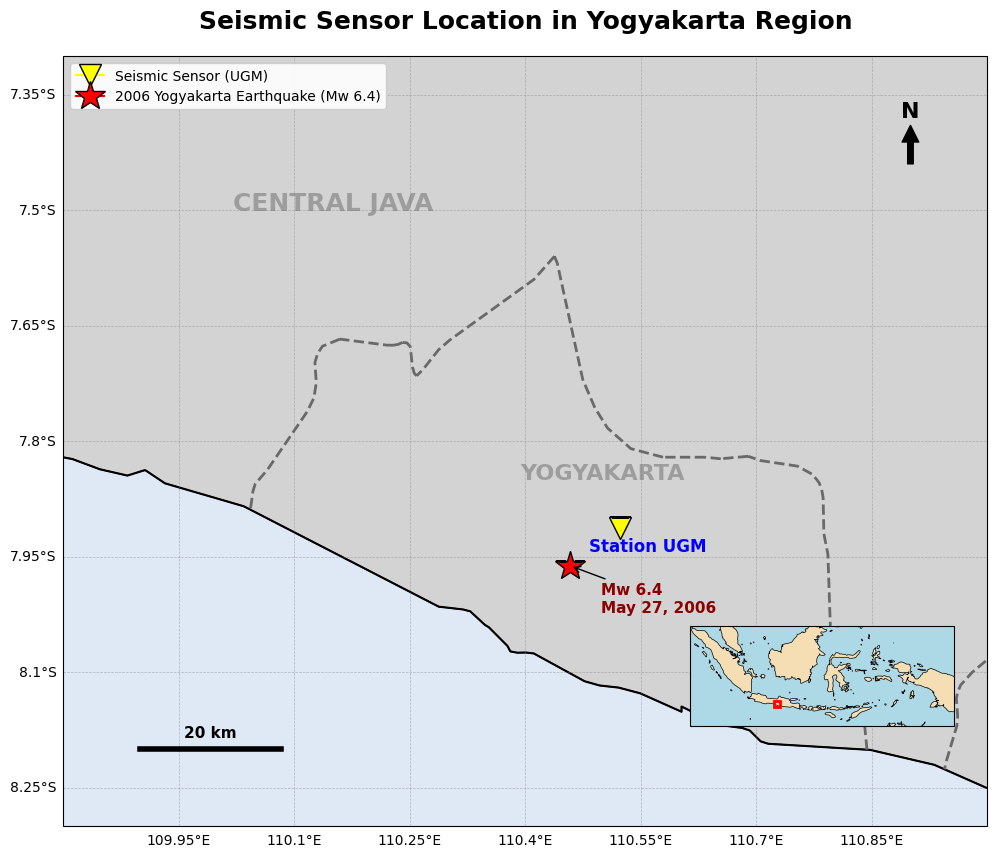

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [6]:
# ==========================================
# CELL 4: DETAILED MAP (YOGYAKARTA REGION)
# ==========================================

# Set figsize to exactly match the 1.2 : 1 aspect ratio of the extent map
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

# Extent for Yogyakarta region (Width = 1.2, Height = 1.0)
extent = [109.8, 111.0, -8.3, -7.3]
ax.set_extent(extent, crs=ccrs.PlateCarree())

# Map Features
ax.add_feature(cfeature.COASTLINE, linewidth=1.5)
ax.add_feature(cfeature.BORDERS, linestyle='-', linewidth=1.5)
ax.add_feature(cfeature.OCEAN, alpha=0.3)
ax.add_feature(cfeature.LAND, edgecolor='black', facecolor='lightgray')
provinces = cfeature.NaturalEarthFeature('cultural', 'admin_1_states_provinces_lines', '10m', facecolor='none')
ax.add_feature(provinces, edgecolor='dimgray', linestyle='--', linewidth=2.0, zorder=2)

# --- 1. LAT/LON GRIDLINES ---
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 10, 'color': 'black'}
gl.ylabel_style = {'size': 10, 'color': 'black'}

# --- 2. NORTH ARROW ---
arrow_x, arrow_y = 110.9, -7.4
ax.text(arrow_x, arrow_y + 0.02, 'N', transform=ccrs.PlateCarree(), fontsize=16, fontweight='bold', ha='center', zorder=10)
ax.annotate('', xy=(arrow_x, arrow_y + 0.01), xytext=(arrow_x, arrow_y - 0.04),
            arrowprops=dict(facecolor='black', width=4, headwidth=12), transform=ccrs.PlateCarree(), zorder=10)

# --- 3. SCALE BAR (~20 km) ---
bar_lon_start = 109.9
bar_lon_end = bar_lon_start + 0.182
bar_lat = -8.2
ax.plot([bar_lon_start, bar_lon_end], [bar_lat, bar_lat], color='black', linewidth=4, transform=ccrs.PlateCarree(), zorder=10)
ax.text((bar_lon_start + bar_lon_end)/2, bar_lat + 0.015, '20 km', transform=ccrs.PlateCarree(), fontsize=11, ha='center', fontweight='bold', zorder=10)

# --- 4. REGIONAL LABELS (Fixed to ax instead of plt) ---
# Using ax.text ensures these labels are drawn on the main map, not the inset map
ax.text(110.15, -7.50, 'CENTRAL JAVA', transform=ccrs.PlateCarree(), fontsize=18, fontweight='bold', color='dimgray', alpha=0.5, ha='center', zorder=4)
ax.text(110.50, -7.85, 'YOGYAKARTA', transform=ccrs.PlateCarree(), fontsize=16, fontweight='bold', color='dimgray', alpha=0.5, ha='center', zorder=4)

# --- 5. INSET MAP (INDONESIA) ---
inset_ax = fig.add_axes([0.65, 0.15, 0.22, 0.22], projection=ccrs.PlateCarree())
inset_ax.set_extent([95, 142, -11, 6])
inset_ax.add_feature(cfeature.LAND, facecolor='wheat')
inset_ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
inset_ax.add_feature(cfeature.COASTLINE, linewidth=0.5)

# Draw red bounding box for zoomed area inside inset
rect = mpatches.Rectangle((extent[0], extent[2]), extent[1]-extent[0], extent[3]-extent[2],
                          linewidth=2, edgecolor='red', facecolor='none', transform=ccrs.PlateCarree(), zorder=10)
inset_ax.add_patch(rect)

# Plot Station UGM on MAIN ax
st_lat, st_lon = inv[0][0].latitude, inv[0][0].longitude
ax.plot(st_lon, st_lat, marker='v', color='yellow', markersize=16, markeredgecolor='black', transform=ccrs.PlateCarree(), label=f'Seismic Sensor ({station})', zorder=5)
ax.text(st_lon - 0.04, st_lat - 0.03, f'Station {station}', transform=ccrs.PlateCarree(), fontsize=12, fontweight='bold', color='blue', zorder=5)

# Plot Earthquake on MAIN ax
eq_lat, eq_lon = -7.962, 110.458
ax.plot(eq_lon, eq_lat, marker='*', color='red', markersize=22, markeredgecolor='black', transform=ccrs.PlateCarree(), label='2006 Yogyakarta Earthquake (Mw 6.4)', zorder=5)
ax.annotate('Mw 6.4\nMay 27, 2006', xy=(eq_lon, eq_lat), xytext=(eq_lon + 0.04, eq_lat - 0.06),
             arrowprops=dict(facecolor='black', arrowstyle='->'), transform=ccrs.PlateCarree(), fontsize=11, color='darkred', fontweight='bold', zorder=6)

# Title & Legend
ax.set_title('Seismic Sensor Location in Yogyakarta Region', pad=20, fontsize=18, fontweight='bold')
ax.legend(loc='upper left', framealpha=0.9)

file_fig1 = 'Figure_1_Map_Yogya.png'
plt.savefig(file_fig1, dpi=300, bbox_inches='tight')
plt.show()
files.download(file_fig1)

Step 5 - Daily Polar Plots

Generates a radial plot to observe the directionality and amplitude of seismic noise over a 24-hour cycle.

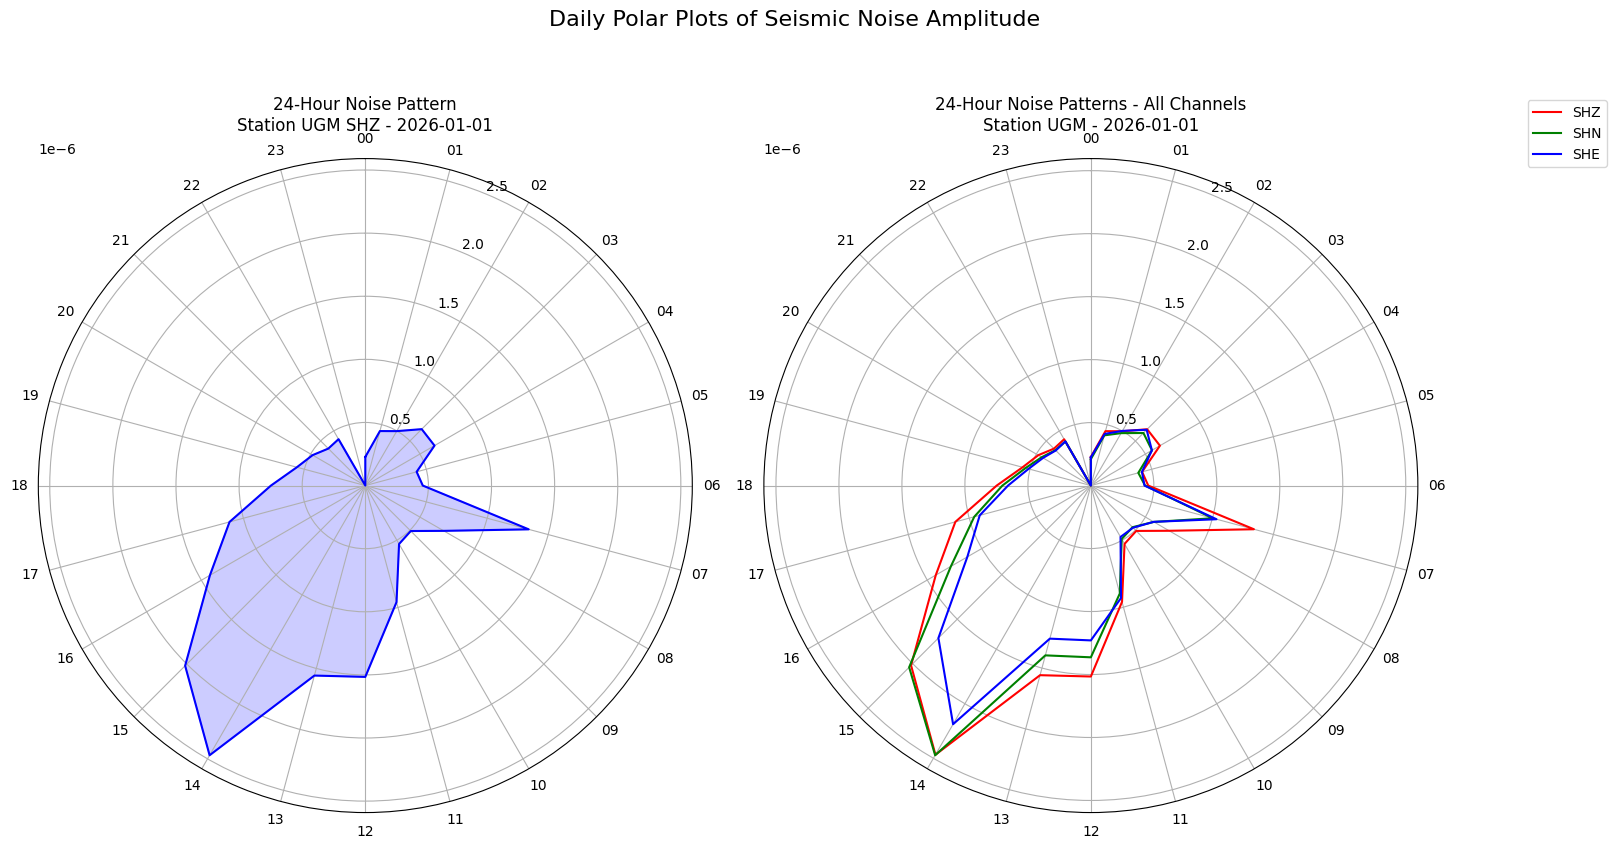

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [7]:
# ==========================================
# CELL 5: 24-HOUR POLAR PLOTS (DUAL PANELS)
# ==========================================
sample_date = df['datetime'].dt.date.unique()[0]
df_day = df[df['datetime'].dt.date == sample_date]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8), subplot_kw={'projection': 'polar'})
angles = np.linspace(0, 2 * np.pi, 24, endpoint=False)

for ax in [ax1, ax2]:
    ax.set_theta_direction(-1)
    ax.set_theta_offset(np.pi / 2)
    ax.set_xticks(angles)
    ax.set_xticklabels([f'{i:02d}' for i in range(24)])

# Left Plot: Vertical Component
z_ch = [ch for ch in df_day['channel'].unique() if 'Z' in ch]
if z_ch:
    ch = z_ch[0]
    subset = df_day[df_day['channel'] == ch].groupby('hour')['rms_noise'].mean().reindex(range(24)).fillna(0)
    values = subset.values
    values = np.concatenate((values, [values[0]]))
    angles_closed = np.concatenate((angles, [angles[0]]))

    ax1.plot(angles_closed, values, color='blue', label=ch)
    ax1.fill(angles_closed, values, color='blue', alpha=0.2)
    ax1.set_title(f'24-Hour Noise Pattern\nStation {station} {ch} - {sample_date}', pad=20)

# Right Plot: All Components
for ch in df_day['channel'].unique():
    subset = df_day[df_day['channel'] == ch].groupby('hour')['rms_noise'].mean().reindex(range(24)).fillna(0)
    values = subset.values
    values = np.concatenate((values, [values[0]]))
    angles_closed = np.concatenate((angles, [angles[0]]))

    col = 'gray'
    if 'Z' in ch: col = 'red'
    elif 'N' in ch: col = 'green'
    elif 'E' in ch: col = 'blue'

    ax2.plot(angles_closed, values, label=ch, color=col)

ax2.set_title(f'24-Hour Noise Patterns - All Channels\nStation {station} - {sample_date}', pad=20)
ax2.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.suptitle('Daily Polar Plots of Seismic Noise Amplitude', fontsize=16, y=1.05)
plt.tight_layout()

file_fig2 = 'Figure_2_Polar_Dual.png'
plt.savefig(file_fig2, dpi=300, bbox_inches='tight')
plt.show()
files.download(file_fig2)

Step 6 - Hourly Statistical Distribution

This block creates boxplots and line plots representing the median statistical noise variance over different hours of the day.

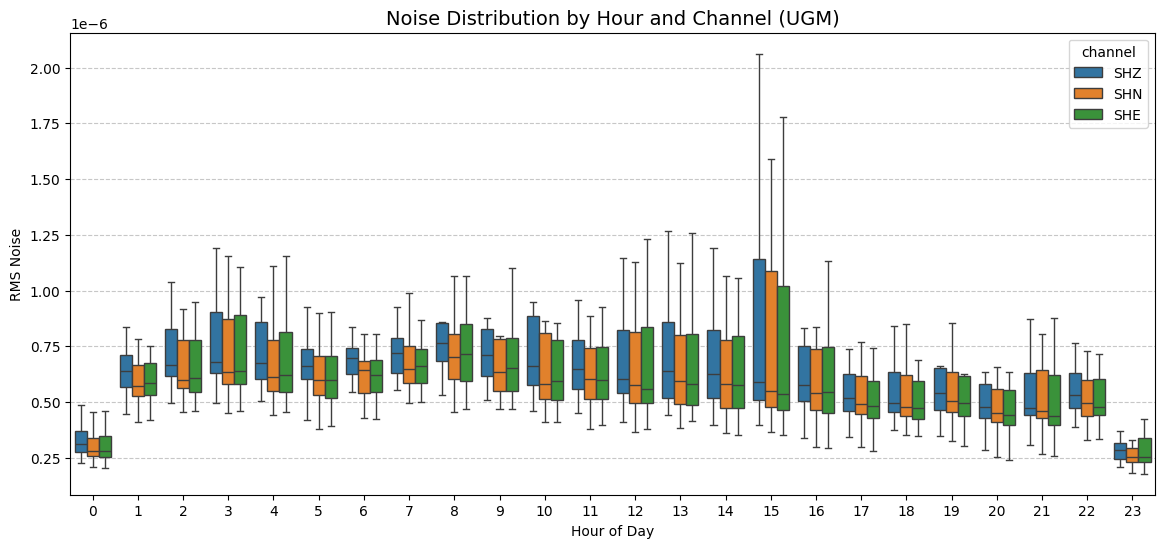

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

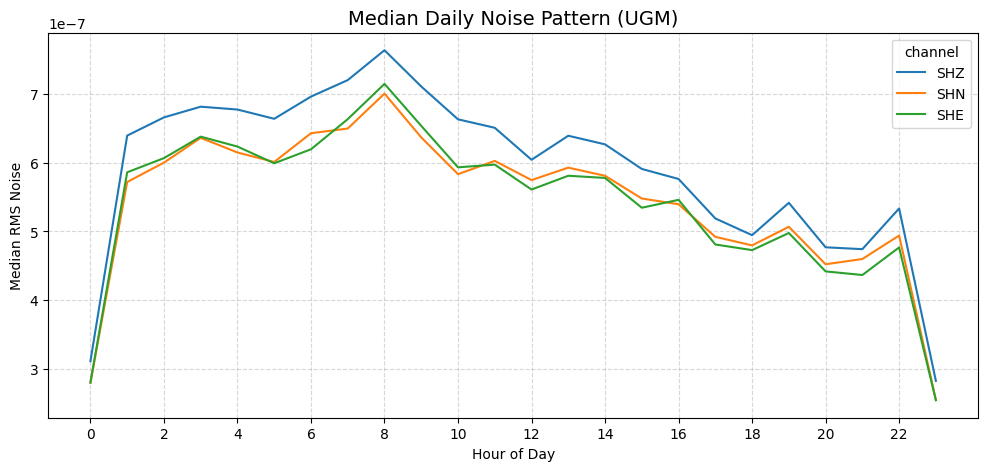

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [8]:
# ==========================================
# CELL 6: BOXPLOT & MEDIAN HOURLY
# ==========================================
# Boxplot
plt.figure(figsize=(14, 6))
sns.boxplot(data=df, x='hour', y='rms_noise', hue='channel', showfliers=False)
plt.title(f'Noise Distribution by Hour and Channel ({station})', fontsize=14)
plt.ylabel('RMS Noise')
plt.xlabel('Hour of Day')
plt.grid(axis='y', linestyle='--', alpha=0.7)
file_fig3 = 'Figure_3_Boxplot_Hourly.png'
plt.savefig(file_fig3, dpi=300, bbox_inches='tight')
plt.show()
files.download(file_fig3)

# Median Lineplot
plt.figure(figsize=(12, 5))
sns.lineplot(data=df, x='hour', y='rms_noise', hue='channel', estimator=np.median, errorbar=None)
plt.title(f'Median Daily Noise Pattern ({station})', fontsize=14)
plt.ylabel('Median RMS Noise')
plt.xlabel('Hour of Day')
plt.xticks(range(0, 24, 2))
plt.grid(axis='both', linestyle='--', alpha=0.5)
file_fig4 = 'Figure_4_Median_Hourly.png'
plt.savefig(file_fig4, dpi=300, bbox_inches='tight')
plt.show()
files.download(file_fig4)

Step 7 - Weekly Trends

Plots the RMS variation separated by the days of the week. Useful for observing human activity drops during weekends.

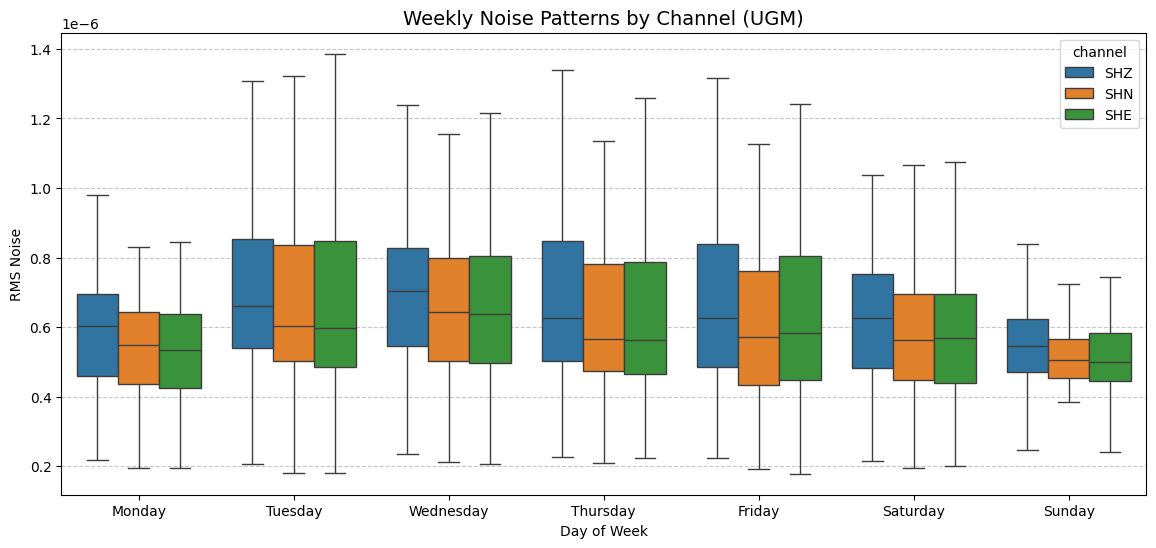

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [9]:
# ==========================================
# CELL 7: WEEKLY PATTERNS
# ==========================================
plt.figure(figsize=(14, 6))
sns.boxplot(data=df, x='day_of_week', y='rms_noise', hue='channel', showfliers=False)
plt.title(f'Weekly Noise Patterns by Channel ({station})', fontsize=14)
plt.ylabel('RMS Noise')
plt.xlabel('Day of Week')
plt.grid(axis='y', linestyle='--', alpha=0.7)

file_fig5 = 'Figure_5_Weekly_Boxplot.png'
plt.savefig(file_fig5, dpi=300, bbox_inches='tight')
plt.show()
files.download(file_fig5)

Step 8 - Spectrogram Heatmap

Provides a top-down view of noise intensity corresponding to dates and hours over the whole downloaded time frame.

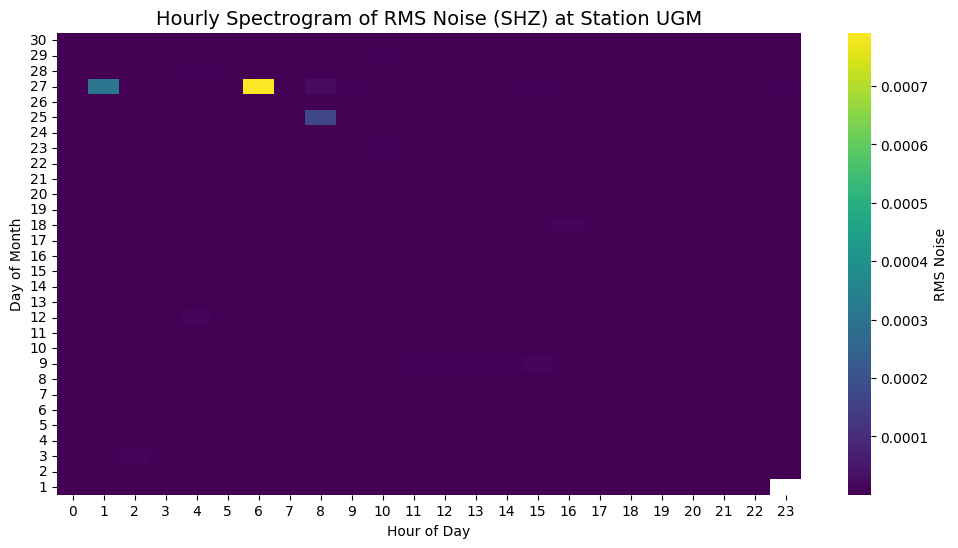

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [10]:
# ==========================================
# CELL 8: HOURLY SPECTROGRAM
# ==========================================
ch_heatmap = [ch for ch in df['channel'].unique() if 'Z' in ch][0]
df_heat = df[df['channel'] == ch_heatmap].pivot_table(index='day_of_month', columns='hour', values='rms_noise', aggfunc=np.median)

plt.figure(figsize=(12, 6))
sns.heatmap(df_heat, cmap='viridis', cbar_kws={'label': 'RMS Noise'})
plt.title(f'Hourly Spectrogram of RMS Noise ({ch_heatmap}) at Station {station}', fontsize=14)
plt.ylabel('Day of Month')
plt.xlabel('Hour of Day')
plt.gca().invert_yaxis()

file_fig6 = 'Figure_6_Spectrogram.png'
plt.savefig(file_fig6, dpi=300, bbox_inches='tight')
plt.show()
files.download(file_fig6)

Step 9 - Fuzzy C-Means (FCM) Clustering

Unsupervised machine learning logic to categorize the data into 5 distinct noise regime clusters.

Running Fuzzy C-Means algorithm...


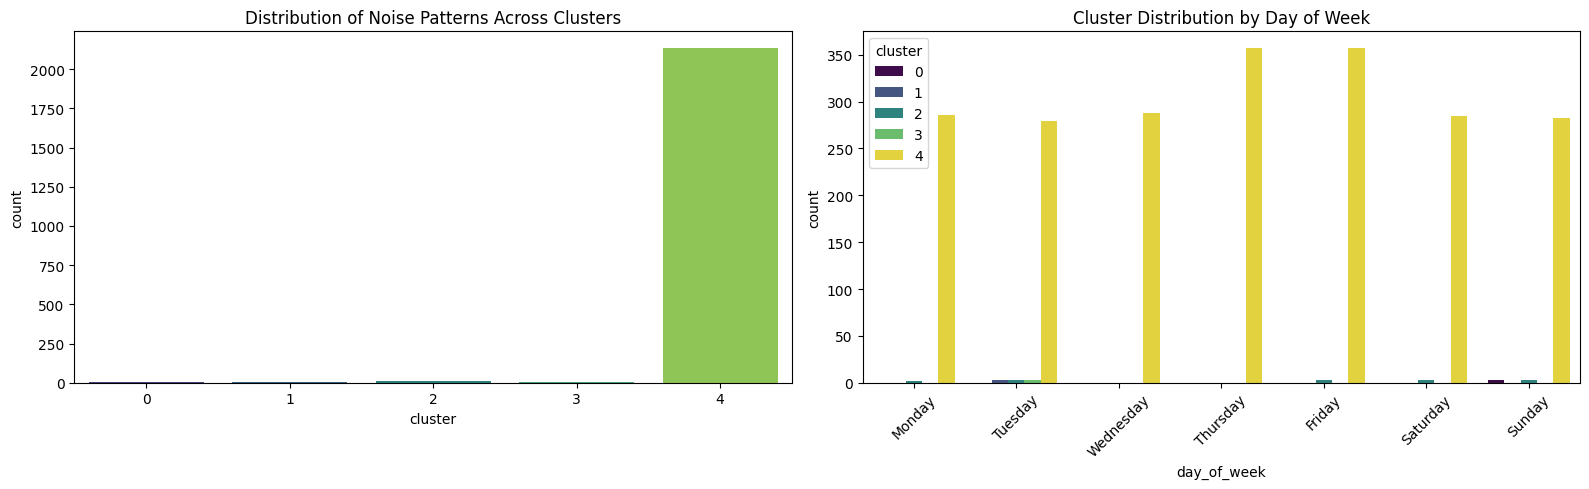

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:
# ==========================================
# CELL 9: FUZZY C-MEANS CLUSTERING
# ==========================================
print("Running Fuzzy C-Means algorithm...")
data_fcm = df['rms_noise'].values.reshape(1, -1)

# FCM Parameters
n_clusters = 5
cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(data_fcm, c=n_clusters, m=2.0, error=1e-5, maxiter=300, init=None)

df['cluster'] = np.argmax(u, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.countplot(data=df, x='cluster', palette='viridis', ax=axes[0])
axes[0].set_title('Distribution of Noise Patterns Across Clusters', fontsize=12)

sns.countplot(data=df, x='day_of_week', hue='cluster', palette='viridis', ax=axes[1])
axes[1].set_title('Cluster Distribution by Day of Week', fontsize=12)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)

plt.tight_layout()
file_fig7 = 'Figure_7_FCM_Clusters.png'
plt.savefig(file_fig7, dpi=300, bbox_inches='tight')
plt.show()
files.download(file_fig7)

In [12]:
# ==========================================
# CELL 10: TABLE 1 (SAVE TO CSV)
# ==========================================
# Classification for Daytime (06:00-18:00) and Nighttime (18:00-06:00)
df['time_period'] = np.where((df['hour'] >= 6) & (df['hour'] < 18), 'Daytime', 'Nighttime')

table_data = []
z_ch = [c for c in df['channel'].unique() if 'Z' in c][0]
z_day_rms = df[(df['channel'] == z_ch) & (df['time_period'] == 'Daytime')]['rms_noise'].median()

for ch in df['channel'].unique():
    ch_data = df[df['channel'] == ch]
    day_rms = ch_data[ch_data['time_period'] == 'Daytime']['rms_noise'].median()
    night_rms = ch_data[ch_data['time_period'] == 'Nighttime']['rms_noise'].median()

    reduction = ((day_rms - night_rms) / day_rms) * 100 if day_rms > 0 else 0

    # Horizontal to Vertical Ratio
    if 'Z' in ch:
        ratio_str = "Reference"
    else:
        ratio = day_rms / z_day_rms
        ratio_str = f"{round(ratio, 1)}x higher than Z"

    table_data.append({
        'Component': ch,
        'Daytime RMS': round(day_rms, 2),
        'Nighttime RMS': round(night_rms, 2),
        'Reduction (%)': f"~{round(reduction, 2)}%",
        'Horizontal-to-Vertical Ratio': ratio_str
    })

df_table1 = pd.DataFrame(table_data)

# Save to CSV and Download
csv_filename = 'Table_1_UGM_Noise_Comparison.csv'
df_table1.to_csv(csv_filename, index=False)
print(f"File {csv_filename} created successfully!")

display(df_table1) # Displaying the table preview in Colab
files.download(csv_filename)

File Table_1_UGM_Noise_Comparison.csv created successfully!


,Component,Daytime RMS,Nighttime RMS,Reduction (%),Horizontal-to-Vertical Ratio
0,SHZ,0.0,0.0,~14.18%,Reference
1,SHN,0.0,0.0,~14.57%,0.9x higher than Z
2,SHE,0.0,0.0,~13.99%,0.9x higher than Z


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Step 11: Local Site Effect Analysis using HVSR (Nakamura Method)

This cell computes the Horizontal-to-Vertical Spectral Ratio (HVSR) to evaluate the local site response and vulnerability. By comparing the spectral amplitude of the merged horizontal components (N and E) against the vertical component (Z), we can identify the fundamental resonance frequency ($f_0$) of the ground beneath the station.

* **Low $f_0$ (e.g., 1-3 Hz):** Indicates thick, soft sediment layers that are highly prone to earthquake amplification.
* **High $f_0$ (e.g., > 5 Hz):** Indicates shallow sediments or stiffer soil.
* **Flat Curve / No Peak:** Indicates the station is built directly on hard bedrock (ideal for a seismic station).

[INFO] Waveform backup found in Drive: /content/drive/MyDrive/HVSR_UGM_1day.mseed
Processing raw counts (without remove_response)...
Calculating Full FFT for 1440 windows...
Applying Konno-Ohmachi Smoothing (b=40)...
✅ Complete! f0 = 1.52 Hz, Amplitude = 1.32


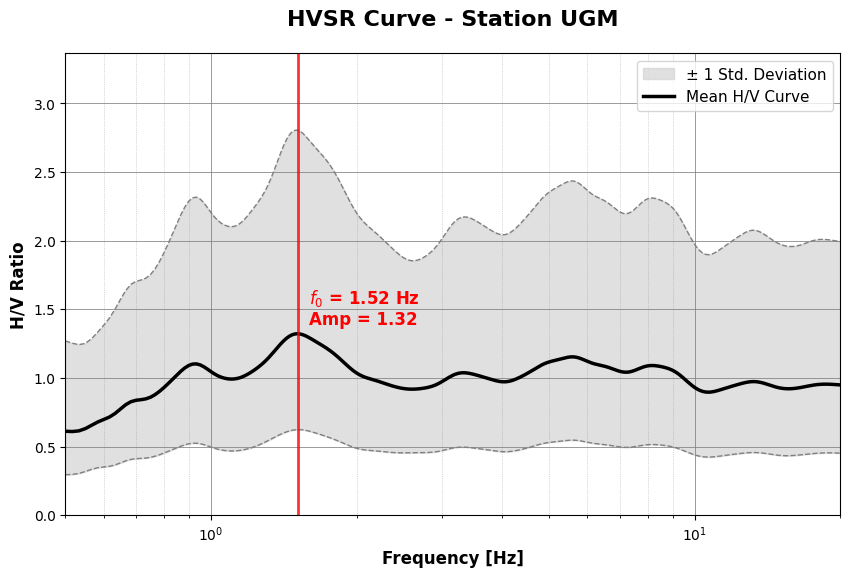

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [13]:
# ==========================================
# CELL 11: HVSR ANALYSIS
# ==========================================

# --- MANUAL KONNO-OHMACHI FUNCTION ---
# Replaces the ObsPy module that causes errors in Google Colab.
# This formula is identical to standard HVSR guidelines.
def konno_ohmachi_smoothing(spectra, freqs, b=40):
    smoothed = np.zeros_like(spectra)
    for i, fc in enumerate(freqs):
        x = b * np.log10(freqs / fc)
        w = np.zeros_like(x)

        # Prevent division by zero when frequency = center frequency
        idx = (x != 0)
        w[idx] = (np.sin(x[idx]) / x[idx]) ** 4
        w[~idx] = 1.0

        # Normalize weights
        w /= np.sum(w)
        smoothed[i] = np.sum(spectra * w)
    return smoothed
# -----------------------------------

client = Client("GFZ")
network = "GE"
station = "UGM"
location = "*"
channel = "SH?"

# 1 Day (Sunday)
t1 = UTCDateTime("2023-08-06T00:00:00")
t2 = t1 + (24 * 3600)
mseed_backup = "/content/drive/MyDrive/HVSR_UGM_1day.mseed"

# --- RESUME & MSEED BACKUP FEATURE ---
if os.path.exists(mseed_backup):
    print(f"[INFO] Waveform backup found in Drive: {mseed_backup}")
    st_hvsr = obspy.read(mseed_backup)
else:
    print("[INFO] No backup found in Drive. Downloading data from server...")
    st_hvsr = client.get_waveforms(network, station, location, channel, t1, t2)
    st_hvsr.write(mseed_backup, format="MSEED")
    print("Backup successful! ✅")

# 1. STANDARD PROCESSING: No remove_response! (Use Raw Counts)
print("Processing raw counts (without remove_response)...")
st_hvsr.detrend("linear")
st_hvsr.merge(method=1, fill_value='interpolate')

tr_z = st_hvsr.select(component="Z")[0]
tr_n = st_hvsr.select(component="N")[0]
tr_e = st_hvsr.select(component="E")[0]

fs = tr_z.stats.sampling_rate

# 2. STANDARD STYLE: 60-second window & 5% Cosine Taper
window_length = 60
n_samples = int(window_length * fs)
taper = cosine_taper(n_samples, p=0.05)
freqs = np.fft.rfftfreq(n_samples, d=1/fs)

# Limit frequency search (0.5 - 20 Hz)
valid_f_idx = np.where((freqs >= 0.5) & (freqs <= 20.0))[0]
freqs_valid = freqs[valid_f_idx]

hvsr_windows = []

print(f"Calculating Full FFT for {len(tr_z.data)//n_samples} windows...")
for i in range(0, len(tr_z.data) - n_samples, n_samples):
    win_z = tr_z.data[i:i+n_samples] * taper
    win_n = tr_n.data[i:i+n_samples] * taper
    win_e = tr_e.data[i:i+n_samples] * taper

    # Fast Fourier Transform (Amplitude)
    amp_z = np.abs(np.fft.rfft(win_z))[valid_f_idx]
    amp_n = np.abs(np.fft.rfft(win_n))[valid_f_idx]
    amp_e = np.abs(np.fft.rfft(win_e))[valid_f_idx]

    # Prevent division by zero
    amp_z[amp_z == 0] = np.finfo(float).eps

    # 3. STANDARD STYLE: Squared Average for Horizontal components
    amp_h = np.sqrt((amp_n**2 + amp_e**2) / 2.0)

    # Raw H/V ratio per window
    hvsr = amp_h / amp_z
    hvsr_windows.append(hvsr)

hvsr_windows = np.array(hvsr_windows)

# 4. STANDARD STYLE: Logarithmic Statistics
with np.errstate(divide='ignore'):
    log_hvsr = np.log(hvsr_windows)

mean_log = np.mean(log_hvsr, axis=0)
std_log = np.std(log_hvsr, axis=0)

hvsr_mean_raw = np.exp(mean_log)
hvsr_plus_raw = np.exp(mean_log + std_log)
hvsr_minus_raw = np.exp(mean_log - std_log)

# 5. STANDARD STYLE: Manual Konno-Ohmachi Smoothing (b=40)
print("Applying Konno-Ohmachi Smoothing (b=40)...")
hvsr_mean = konno_ohmachi_smoothing(hvsr_mean_raw, freqs_valid, b=40)
hvsr_plus = konno_ohmachi_smoothing(hvsr_plus_raw, freqs_valid, b=40)
hvsr_minus = konno_ohmachi_smoothing(hvsr_minus_raw, freqs_valid, b=40)

# Find dominant frequency (f0)
peak_idx = np.argmax(hvsr_mean)
f0 = freqs_valid[peak_idx]
amp_max = hvsr_mean[peak_idx]

print(f"✅ Complete! f0 = {f0:.2f} Hz, Amplitude = {amp_max:.2f}")

# --- PLOTTING ---
plt.figure(figsize=(10, 6))

plt.fill_between(freqs_valid, hvsr_minus, hvsr_plus, color='lightgray', alpha=0.7, label='± 1 Std. Deviation')
plt.plot(freqs_valid, hvsr_plus, color='gray', linestyle='--', linewidth=1)
plt.plot(freqs_valid, hvsr_minus, color='gray', linestyle='--', linewidth=1)
plt.plot(freqs_valid, hvsr_mean, color='black', linewidth=2.5, label='Mean H/V Curve')

plt.axvline(f0, color='red', linestyle='-', linewidth=2, alpha=0.8)
plt.text(f0 * 1.05, amp_max * 1.05, f'$f_0$ = {f0:.2f} Hz\nAmp = {amp_max:.2f}', color='red', fontweight='bold', fontsize=12)

plt.xscale('log')
plt.xlim(0.5, 20)

y_max = min(np.max(hvsr_plus) * 1.2, 8)
plt.ylim(0, y_max)

plt.title(f'HVSR Curve - Station {station}', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Frequency [Hz]', fontsize=12, fontweight='bold')
plt.ylabel('H/V Ratio', fontsize=12, fontweight='bold')

plt.grid(True, which="major", color='gray', linestyle='-', linewidth=0.7, alpha=0.8)
plt.grid(True, which="minor", color='gray', linestyle=':', linewidth=0.5, alpha=0.6)
plt.legend(fontsize=11, loc='upper right')

file_fig8 = 'Figure_8_HVSR_Curve.png'
plt.savefig(file_fig8, dpi=300, bbox_inches='tight')
plt.show()

files.download(file_fig8)